# KellyLab: how much should you bet?

A study of the Kelly criterion on **simulated data only**. It extends my calculator app [KellyEdge](https://github.com/YOJITM05/kellyedge), which turns the formula into a stake. KellyEdge never asks the harder questions: *where does the formula come from, how risky is it, and what happens when my estimate of the odds is wrong?* This notebook answers those with derivations, simulations and tests.

**Conventions.** `p` = win probability. `b` = net odds (a win pays `b` per 1 staked, a loss costs the 1 staked; `b` is `R` in KellyEdge). `f` = fraction of the *current* bankroll staked on every bet.

**What this is not.** Every number here comes from a random-number generator with a fixed seed. Bets are independent, odds are fixed and known, and there are no costs, taxes or limits. It is a teaching study, not trading advice, and it says nothing about real markets.

**Authorship.** Built with AI assistance (Claude). The questions at the end are my check that I can explain every step.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import kellylab as kl

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
SEED = 42
P, B = 0.55, 2.0                      # KellyEdge's first test case
F_STAR = kl.kelly_fraction(P, B)
print(f"p = {P}, b = {B}  ->  full Kelly f* = {F_STAR:.3f} ({F_STAR:.1%} of the bankroll)")
print(f"expected profit per 1 staked = {P * B - (1 - P):.2f}")

p = 0.55, b = 2.0  ->  full Kelly f* = 0.325 (32.5% of the bankroll)
expected profit per 1 staked = 0.65


## 1. Where the formula comes from

Stake a fixed fraction $f$ of the current bankroll on each bet. After a win the bankroll is multiplied by $1+bf$; after a loss by $1-f$. After $n$ bets with $k$ wins:

$$W_n = W_0\,(1+bf)^{k}\,(1-f)^{n-k}$$

Take logs and divide by $n$. By the law of large numbers $k/n \to p$, so the long-run growth rate per bet is

$$g(f) = p\,\ln(1+bf) + (1-p)\,\ln(1-f).$$

Differentiate and set the derivative to zero:

$$g'(f) = \frac{pb}{1+bf} - \frac{1-p}{1-f} = 0 \;\Longrightarrow\; pb(1-f) = (1-p)(1+bf) \;\Longrightarrow\; f^{*} = \frac{pb-(1-p)}{b} = p - \frac{1-p}{b}.$$

This is exactly KellyEdge's `W - (1 - W) / R`. The second derivative $g''(f) = -\frac{pb^2}{(1+bf)^2} - \frac{1-p}{(1-f)^2}$ is negative, so $f^*$ is a maximum. The idea: among all fixed-fraction strategies, $f^*$ makes the typical bankroll grow fastest.

For small, frequent returns with mean $\mu$ and variance $\sigma^2$ per period, $g(f)\approx f\mu - \tfrac12 f^2\sigma^2$, which gives the continuous version $f^{*}=\mu/\sigma^{2}$ (section 6).


peak growth g(f*) = 0.0986 per bet  (bankroll doubles in about 7 bets)
growth turns negative at about f = 0.633  (1.95 x Kelly)


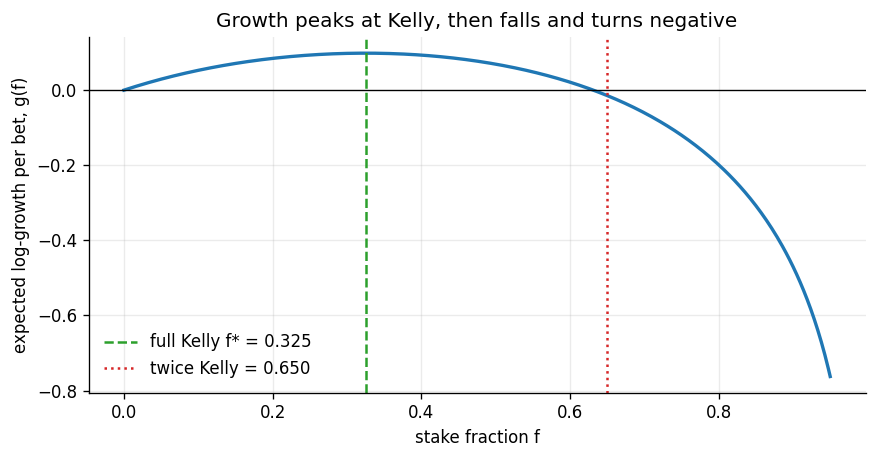

In [2]:
f = np.linspace(0.0, 0.95, 400)
g = kl.log_growth(f, P, B)
G_STAR = float(kl.log_growth(F_STAR, P, B))
F_ZERO = float(f[(f > F_STAR) & (g <= 0)][0])          # first stake above Kelly where growth is no longer positive

fig, ax = plt.subplots(figsize=(7.4, 3.9))
ax.plot(f, g, lw=2, color="tab:blue")
ax.axhline(0, color="k", lw=0.8)
ax.axvline(F_STAR, color="tab:green", ls="--", label=f"full Kelly f* = {F_STAR:.3f}")
ax.axvline(2 * F_STAR, color="tab:red", ls=":", label=f"twice Kelly = {2 * F_STAR:.3f}")
ax.set_xlabel("stake fraction f"); ax.set_ylabel("expected log-growth per bet, g(f)")
ax.set_title("Growth peaks at Kelly, then falls and turns negative")
ax.legend(frameon=False)
fig.tight_layout()

print(f"peak growth g(f*) = {G_STAR:.4f} per bet  (bankroll doubles in about {np.log(2) / G_STAR:.0f} bets)")
print(f"growth turns negative at about f = {F_ZERO:.3f}  ({F_ZERO / F_STAR:.2f} x Kelly)")

In [3]:
# What share of the best growth does a fraction k of Kelly keep?  Exact versus the small-edge rule k(2-k).
P2, B2 = 0.505, 1.0                                   # tiny edge, where the k(2-k) rule is accurate
f2 = kl.kelly_fraction(P2, B2); g2 = float(kl.log_growth(f2, P2, B2))
print(f"{'k':>5} | {'strong edge (p=.55,b=2)':>24} | {'tiny edge (p=.505,b=1)':>23} | {'rule k(2-k)':>11}")
for k in [0.25, 0.5, 0.75, 1.0, 1.5, 2.0]:
    r1 = float(kl.log_growth(k * F_STAR, P, B)) / G_STAR
    r2 = float(kl.log_growth(k * f2, P2, B2)) / g2
    print(f"{k:>5.2f} | {r1:>24.3f} | {r2:>23.3f} | {k * (2 - k):>11.3f}")

    k |  strong edge (p=.55,b=2) |  tiny edge (p=.505,b=1) | rule k(2-k)
 0.25 |                    0.453 |                   0.437 |       0.438
 0.50 |                    0.761 |                   0.750 |       0.750
 0.75 |                    0.940 |                   0.937 |       0.938
 1.00 |                    1.000 |                   1.000 |       1.000
 1.50 |                    0.746 |                   0.750 |       0.750
 2.00 |                   -0.145 |                  -0.000 |       0.000


**Reading it.** For a tiny edge, half-Kelly keeps about 75% of the growth and twice Kelly keeps none. That is the textbook rule $k(2-k)$. For the larger edge here the curve is not symmetric: half-Kelly keeps 76%, and staking 1.95x Kelly already gives zero growth. Betting too much is punished harder than betting too little.


## 2. Simulation: what does the ride look like?

10,000 independent bankrolls, 500 bets each, same odds as above. For each stake size I record the growth actually achieved, and three risks: ending below the start, the worst peak-to-trough drawdown (median across paths), and falling below 1% of the starting bankroll at some point (a practical meaning of ruin, since a fixed fraction never reaches exactly zero).

In [4]:
N_PATHS, N_BETS = 10_000, 500
MULTS = [0.25, 0.5, 1.0, 1.5, 2.0]
stats, finals, sample = {}, {}, {}
for m in MULTS:
    w = kl.simulate_paths(P, B, m * F_STAR, N_PATHS, N_BETS, seed=SEED)
    stats[m] = kl.path_stats(w)
    finals[m] = w[:, -1].copy()
    sample[m] = w[:30].copy()
    del w

print(f"{'stake':>9} {'f':>6} | {'median end':>12} {'mean end':>13} {'5th pct':>9} {'95th pct':>11} | {'growth/bet':>10} {'theory':>8} | {'end<start':>9} {'worst DD (med)':>14} {'<1% ruin':>8}")
for m in MULTS:
    s = stats[m]
    th = float(kl.log_growth(m * F_STAR, P, B))
    print(f"{m:>6.2f}xK {m * F_STAR:>6.3f} | {s['median_final']:>12.3g} {s['mean_final']:>13.3g} {s['p05_final']:>9.3g} {s['p95_final']:>11.3g} | "
          f"{s['median_growth_per_bet']:>10.4f} {th:>8.4f} | {s['prob_below_start']:>9.1%} {s['median_max_drawdown']:>14.1%} {s['prob_ruin']:>8.1%}")

    stake      f |   median end      mean end   5th pct    95th pct | growth/bet   theory | end<start worst DD (med) <1% ruin
  0.25xK  0.081 |     5.04e+09      1.33e+11  7.29e+07    3.48e+11 |     0.0447   0.0447 |      0.0%          50.2%     0.0%
  0.50xK  0.163 |     1.91e+16      6.42e+20  4.95e+12    7.36e+19 |     0.0750   0.0750 |      0.0%          78.4%     0.0%
  1.00xK  0.325 |     2.52e+21       2.2e+33   2.6e+14    2.45e+28 |     0.0986   0.0986 |      0.0%          98.0%     0.7%
  1.50xK  0.488 |     9.16e+15      9.66e+35  2.61e+05    3.22e+26 |     0.0735   0.0735 |      0.8%         100.0%    20.1%
  2.00xK  0.650 |     0.000777       2.6e+26  1.49e-18    4.06e+11 |    -0.0143  -0.0143 |     62.0%         100.0%    87.1%


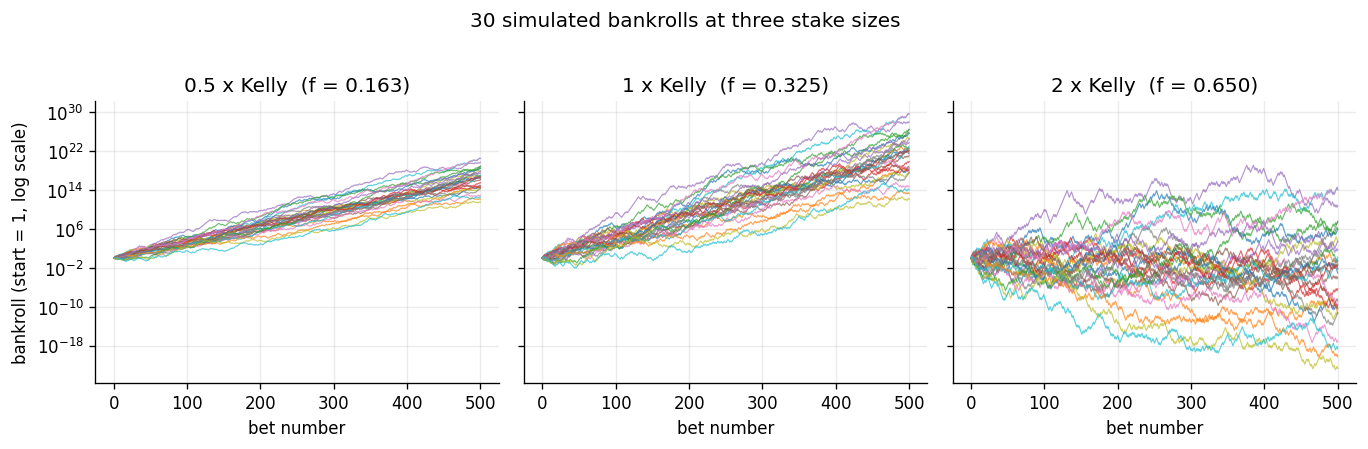

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.6), sharey=True)
for ax, m in zip(axes, [0.5, 1.0, 2.0]):
    for row in sample[m]:
        ax.plot(row, lw=0.7, alpha=0.7)
    ax.set_yscale("log"); ax.set_title(f"{m:g} x Kelly  (f = {m * F_STAR:.3f})"); ax.set_xlabel("bet number")
axes[0].set_ylabel("bankroll (start = 1, log scale)")
fig.suptitle("30 simulated bankrolls at three stake sizes", y=1.02)
fig.tight_layout()

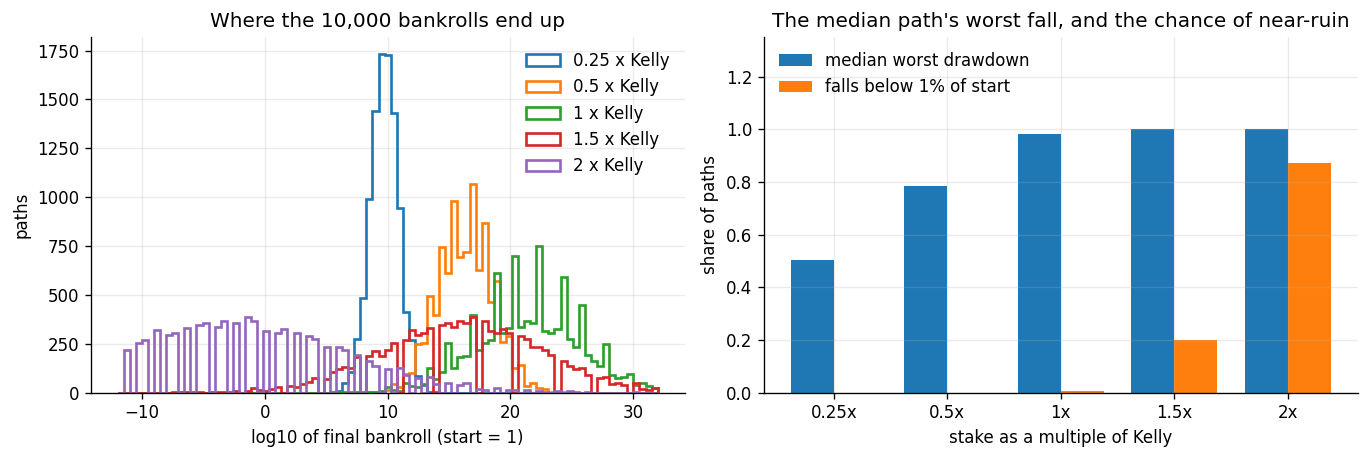

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))
bins = np.linspace(-12, 32, 90)
for m in MULTS:
    axes[0].hist(np.log10(finals[m]), bins=bins, histtype="step", lw=1.6, label=f"{m:g} x Kelly")
axes[0].set_xlabel("log10 of final bankroll (start = 1)"); axes[0].set_ylabel("paths"); axes[0].legend(frameon=False)
axes[0].set_title("Where the 10,000 bankrolls end up")
x = np.arange(len(MULTS)); wd = 0.38
axes[1].bar(x - wd / 2, [stats[m]["median_max_drawdown"] for m in MULTS], wd, label="median worst drawdown")
axes[1].bar(x + wd / 2, [stats[m]["prob_ruin"] for m in MULTS], wd, label="falls below 1% of start")
axes[1].set_xticks(x); axes[1].set_xticklabels([f"{m:g}x" for m in MULTS]); axes[1].set_xlabel("stake as a multiple of Kelly")
axes[1].set_ylabel("share of paths"); axes[1].set_ylim(0, 1.35); axes[1].legend(frameon=False, loc="upper left")
axes[1].set_title("The median path's worst fall, and the chance of near-ruin")
fig.tight_layout()

**Reading it.**
- **Median versus mean.** At full Kelly the median bankroll grows 2.52e+21-fold over 500 bets, but the sample mean is 2.2e+33-fold, and the theoretical expected value, (1 + f x EV)^n, is 4.14e+41-fold. The expectation is carried by paths so lucky that they never appear in 10,000 draws. That is why Kelly targets *log* growth, which is what a typical path sees.
- **Drawdowns are large even at Kelly.** The median path's worst peak-to-trough fall is 98% at full Kelly, 78% at half-Kelly and 50% at quarter-Kelly, in exchange for 76% and 45% of full Kelly's growth. (With this large an edge, two losses in a row at full Kelly already cost 54%, so a 50% drawdown happens on nearly every path.)
- **Above Kelly the growth drops and ruin appears.** At 1.5x Kelly growth is lower than at 1.0x and 20% of paths fall below 1% of the start at some point (versus 0.7% at Kelly). At 2x the median path loses money: 62% of paths end below the start and 87% touch near-ruin.


## 3. Estimation error: the formula assumes you know `p`

In practice `p` is estimated from past outcomes. Here a trader sees `n` past trades, estimates `p` as the share of wins, and bets Kelly (times a fraction `k`) computed from that estimate. I then evaluate the **true** expected growth of that stake. "Share of optimum" is the achieved growth divided by the best possible growth at the true `p`; a negative value means the stake loses money in the long run.

A rule of thumb from a small-edge approximation: if the edge $\mu = pb-(1-p)$ is estimated with standard deviation $s=(b+1)\sqrt{p(1-p)/n}$, the best fraction of Kelly is $k=\mu^2/(\mu^2+s^2)$. The more noise relative to the edge, the smaller the fraction.

In [7]:
CASES = {"strong edge (p=0.55, b=2)": (0.55, 2.0), "weak edge (p=0.52, b=1)": (0.52, 1.0)}
NS_TRADES = [10, 20, 50, 100, 500, 2000]
KGRID = np.array([0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2])
est = {}
for name, (p, b) in CASES.items():
    for n in NS_TRADES:
        est[(name, n)] = np.array([kl.estimation_error_experiment(p, b, n, k, n_draws=40_000, seed=SEED)["share_of_optimum"] for k in KGRID])

for name, (p, b) in CASES.items():
    print(f"--- {name}: true full Kelly = {kl.kelly_fraction(p, b):.3f}")
    print(f"{'trades n':>9} | {'best k (sim)':>12} {'rule of thumb':>14} | {'share at best k':>15} {'share at k=1':>13} {'share at k=0.5':>15} | {'P(stake>2x Kelly), k=1':>22}")
    for n in NS_TRADES:
        sh = est[(name, n)]; i = int(np.argmax(sh))
        ov = kl.estimation_error_experiment(p, b, n, 1.0, seed=SEED)["prob_overbet_2x"]
        print(f"{n:>9} | {KGRID[i]:>12.2f} {kl.shrinkage_fraction(p, b, n):>14.2f} | {sh[i]:>15.2f} {sh[list(KGRID).index(1.0)]:>13.2f} {sh[list(KGRID).index(0.5)]:>15.2f} | {ov:>22.1%}")

--- strong edge (p=0.55, b=2): true full Kelly = 0.325
 trades n | best k (sim)  rule of thumb | share at best k  share at k=1  share at k=0.5 | P(stake>2x Kelly), k=1
       10 |         0.70           0.65 |            0.70          0.47            0.66 |                   9.8%
       20 |         0.80           0.79 |            0.80          0.74            0.70 |                   1.9%
       50 |         0.90           0.90 |            0.91          0.89            0.73 |                   0.1%
      100 |         0.90           0.95 |            0.95          0.95            0.75 |                   0.0%
      500 |         1.00           0.99 |            0.99          0.99            0.76 |                   0.0%
     2000 |         1.00           1.00 |            1.00          1.00            0.76 |                   0.0%
--- weak edge (p=0.52, b=1): true full Kelly = 0.040
 trades n | best k (sim)  rule of thumb | share at best k  share at k=1  share at k=0.5 | P(stake>2x 

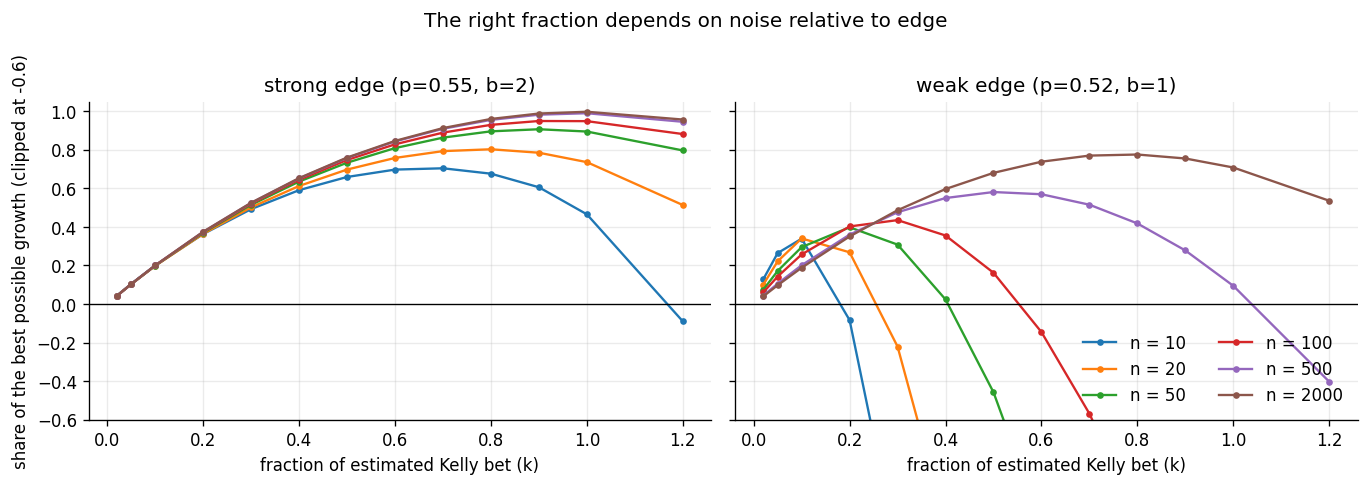

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9), sharey=True)
for ax, (name, (p, b)) in zip(axes, CASES.items()):
    for n in NS_TRADES:
        ax.plot(KGRID, est[(name, n)], marker="o", ms=3, lw=1.4, label=f"n = {n}")
    ax.axhline(0, color="k", lw=0.8); ax.set_ylim(-0.6, 1.05)
    ax.set_title(name); ax.set_xlabel("fraction of estimated Kelly bet (k)")
axes[0].set_ylabel("share of the best possible growth (clipped at -0.6)"); axes[1].legend(frameon=False, ncol=2)
fig.suptitle("The right fraction depends on noise relative to edge", y=1.02)
fig.tight_layout()

**Reading it.** With a strong edge the estimate is good enough: after 50 trades the best fraction is about 0.9 of Kelly, and with 2,000 trades it is 1.0. Half-Kelly gives up growth there. With a weak edge the picture flips: after 100 trades, betting the full estimated Kelly has *negative* long-run growth (share -2.6), and the best fraction is only about 0.3. Fractional Kelly is not a magic safety setting. It is shrinkage: use less of the formula when your estimate is noisy compared with your edge. Real trading edges are usually small, so this is the common case. The rule of thumb matches the strong-edge case closely but undershoots the simulated best fraction in the weak-edge case (for example 0.14 against 0.3 at 100 trades), partly because a trader never bets on a negative estimate. Very negative shares (for example -40) mean the stake destroys wealth at many times the optimal growth rate in magnitude; the cause is occasional huge overbets after a lucky run of wins.


## 4. Model risk: what if the true win probability is lower than you think?

Sizing at full, half and quarter Kelly *assuming* `p = 0.55` and `b = 2`, what is the long-run growth if the true win probability is something else?

stake 0.25 x Kelly: growth is negative if the true p is below 0.360
stake 0.5 x Kelly: growth is negative if the true p is below 0.387
stake 1 x Kelly: growth is negative if the true p is below 0.440


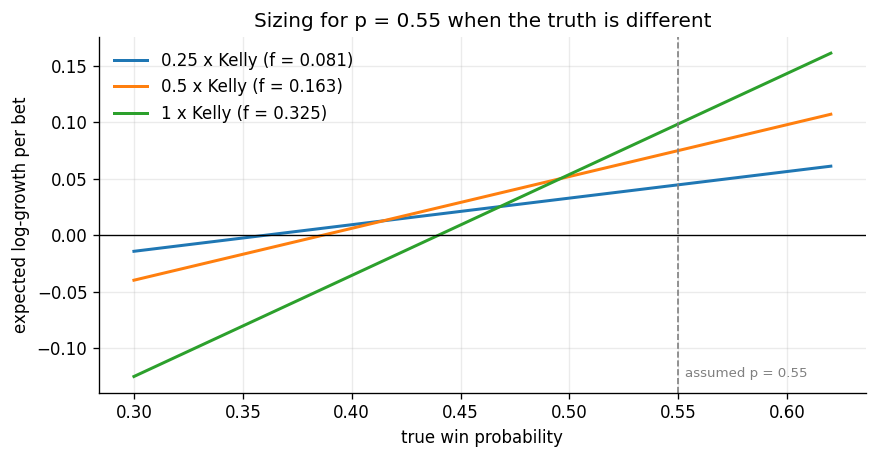

In [9]:
p_true = np.linspace(0.30, 0.62, 200)
fig, ax = plt.subplots(figsize=(7.4, 3.9))
BE = {}
for m in (0.25, 0.5, 1.0):
    fm = m * F_STAR
    ax.plot(p_true, [float(kl.log_growth(fm, pt, B)) for pt in p_true], lw=1.8, label=f"{m:g} x Kelly (f = {fm:.3f})")
    BE[m] = kl.breakeven_true_p(fm, B)
ax.axhline(0, color="k", lw=0.8); ax.axvline(P, color="gray", ls="--", lw=1)
ax.text(P + 0.003, ax.get_ylim()[0] * 0.9, "assumed p = 0.55", fontsize=8, color="gray")
ax.set_xlabel("true win probability"); ax.set_ylabel("expected log-growth per bet"); ax.set_title("Sizing for p = 0.55 when the truth is different")
ax.legend(frameon=False, loc="upper left"); fig.tight_layout()
for m, be in BE.items():
    print(f"stake {m:g} x Kelly: growth is negative if the true p is below {be:.3f}")

**Reading it.** The assumed `p` is 0.55. Full Kelly turns unprofitable if the true win probability is below 0.440; half-Kelly tolerates anything above 0.387; quarter-Kelly above 0.360. Smaller stakes widen the margin for being wrong.


## 5. The continuous version: $f^{*}=\mu/\sigma^{2}$

For an asset with small, frequent returns (mean excess return $\mu$, variance $\sigma^2$ per year), growth is approximately $g(f)\approx f\mu-\tfrac12 f^2\sigma^2$, maximised at $f^{*}=\mu/\sigma^{2}$. Here $\mu=8\%$ and $\sigma=20\%$ a year, simulated as 2,000,000 normal daily returns, with the same draws reused for every $f$.

mu/sigma^2 = 2.00; simulated best leverage on the grid = 2.05
growth at Kelly: simulated 0.0836, approximation 0.0800 per year
growth at 2x Kelly (leverage 4.0): simulated 0.0066


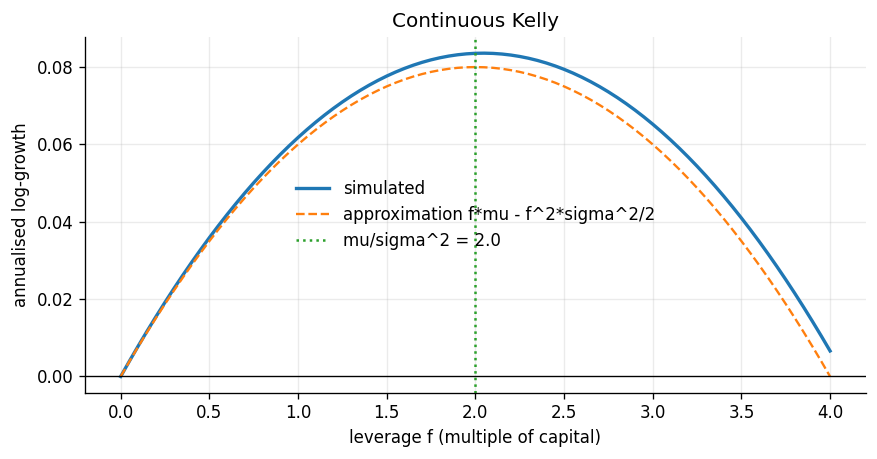

In [10]:
MU, SIGMA, DAYS = 0.08, 0.20, 252
rng = np.random.default_rng(SEED)
r = rng.normal(MU / DAYS, SIGMA / np.sqrt(DAYS), 2_000_000)
fgrid = np.linspace(0.0, 4.0, 81)
g_mc = np.array([np.mean(np.log1p(ff * r)) for ff in fgrid]) * DAYS      # annualised
g_quad = fgrid * MU - 0.5 * fgrid**2 * SIGMA**2
F_CONT = kl.gaussian_kelly(MU, SIGMA**2)

fig, ax = plt.subplots(figsize=(7.4, 3.9))
ax.plot(fgrid, g_mc, lw=2, label="simulated")
ax.plot(fgrid, g_quad, ls="--", lw=1.4, label="approximation f*mu - f^2*sigma^2/2")
ax.axvline(F_CONT, color="tab:green", ls=":", label=f"mu/sigma^2 = {F_CONT:.1f}")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("leverage f (multiple of capital)"); ax.set_ylabel("annualised log-growth"); ax.set_title("Continuous Kelly")
ax.legend(frameon=False); fig.tight_layout()
print(f"mu/sigma^2 = {F_CONT:.2f}; simulated best leverage on the grid = {fgrid[g_mc.argmax()]:.2f}")
print(f"growth at Kelly: simulated {g_mc.max():.4f}, approximation {g_quad.max():.4f} per year")
print(f"growth at 2x Kelly (leverage {2 * F_CONT:.1f}): simulated {g_mc[np.argmin(abs(fgrid - 2 * F_CONT))]:.4f}")

**Reading it.** Kelly leverage is 2.0x capital, which most investors cannot or should not use, and the simulation assumes normal returns with no fat tails. Overshooting to twice Kelly takes growth to roughly zero. This is the same asymmetry as in the discrete case.


## 6. What this study does not show

- **Independence and fixed odds.** Real bets and trades are correlated, and `p` and `b` change over time.
- **Known edge.** Section 3 relaxes this only partly: it adds noise to `p` but assumes `p` itself never changes.
- **No costs.** Fees, slippage, taxes and financing change the optimum.
- **Single bet at a time.** With several bets or assets at once, the Kelly stake is a vector that depends on their covariances.
- **Normal returns in section 5.** Real returns have fat tails, so leverage near $\mu/\sigma^2$ is far more dangerous than shown.
- **Simulated data.** Nothing here has been tested on market data.

## 7. Explain it back (my check that I understand this)

Write your own answer first, then compare.

**1. Derive the Kelly fraction from the log-growth function.** Write $g(f)=p\ln(1+bf)+(1-p)\ln(1-f)$, set $g'(f)=0$, and solve to get $f^*=p-(1-p)/b$. The second derivative is negative, so it is a maximum.

**2. Why maximise log wealth rather than expected wealth?** Expected wealth is maximised by staking everything, which loses everything with probability one in the long run. $\ln W_n/n\to g(f)$, so log growth is what a typical path actually experiences. Section 2 shows the mean is dragged up by a few lucky paths while the median is what most paths see.

**3. What does a zero or negative $f^*$ mean?** No edge or a negative edge: do not bet.

**4. Why can staking twice Kelly lose money even with an edge?** Growth is $f\mu-\tfrac12 f^2\sigma^2$-shaped: the volatility penalty grows with $f^2$ while the gain grows with $f$. Near twice Kelly they cancel (exactly for a small edge).

**5. How much growth does half-Kelly keep, and what does it save?** About 75% of the growth for a small edge ($k(2-k)$), and it lowers drawdown and ruin probabilities a lot (see the section 2 table).

**6. Why does estimation error make a fraction of Kelly attractive?** Overbetting is punished more than underbetting, and estimates of `p` are noisy. A rule of thumb: $k=\mu^2/(\mu^2+s^2)$, where $s$ is the noise in the estimated edge.

**7. When is full Kelly fine?** When the edge is large relative to the noise in its estimate, for example a strong edge with thousands of observations (section 3).

**8. What does $f^*=\mu/\sigma^2$ mean and what is the catch?** Optimal leverage for a normally distributed asset. With $\mu=8\%$, $\sigma=20\%$ it is 2x. The catch is fat tails, changing parameters, and margin limits.

**9. Name three assumptions here that real markets break.** Independent bets; fixed known odds; no costs; normal returns; one bet at a time.

**10. How would you extend this to several bets at once?** Size with the vector $f=\Sigma^{-1}\mu$ (small returns), where $\Sigma$ is the covariance matrix; correlated bets reduce the stake on each.


## 8. Reproduce

```
pip install -r requirements.txt
python -m pytest            # 17 tests for the helper functions
jupyter notebook KellyLab.ipynb
```
All random draws use `SEED = 42`.